## 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

d:\behaviour_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [6]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 83335.23 examples/s]


In [7]:
label_names = emotion_dataset['train'].features['label'].names

In [8]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [9]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [10]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [11]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='str', name='label')

<Axes: xlabel='label', ylabel='count'>

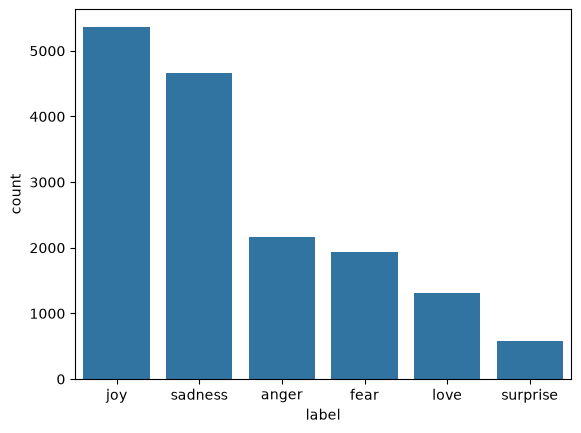

In [12]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [13]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [18]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

### 6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\behaviour_analysis\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.1554 - loss: 1.9072 - val_accuracy: 0.1720 - val_loss: 1.7843
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.1663 - loss: 1.8035 - val_accuracy: 0.1330 - val_loss: 1.8032
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1534 - loss: 1.7849 - val_accuracy: 0.1460 - val_loss: 1.7740
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.1485 - loss: 1.7745 - val_accuracy: 0.1230 - val_loss: 1.8186
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.1506 - loss: 1.7571 - val_accuracy: 0.2075 - val_loss: 1.7843
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.1721 - loss: 1.7315 - val_accuracy: 0.1480 - val_loss: 1.7881
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1460 - loss: 1.7740
RNN Loss: 1.774024486541748
RNN Accuracy: 0.1459999978542328


### 6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [22]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.1567 - loss: 1.7959 - val_accuracy: 0.1135 - val_loss: 1.7891
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.1404 - loss: 1.7940 - val_accuracy: 0.1230 - val_loss: 1.7876
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.1462 - loss: 1.7930 - val_accuracy: 0.1115 - val_loss: 1.7894
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.1489 - loss: 1.7931 - val_accuracy: 0.0405 - val_loss: 1.8057
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.1503 - loss: 1.7977 - val_accuracy: 0.0795 - val_loss: 1.7831
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.1403 - loss: 1.7939 - val_accuracy: 0.0330 - val_loss: 1.7977
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 146ms/step - accuracy: 0.1412 - loss: 1.7926 - val_accuracy: 0.0330 - val_loss: 1.7958
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 194ms/step - accuracy: 0.1109 - loss: 1.7925 

### 6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [23]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.1526 - loss: 1.7964 - val_accuracy: 0.1120 - val_loss: 1.8217
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1528 - loss: 1.7951 - val_accuracy: 0.1370 - val_loss: 1.8102
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.1529 - loss: 1.7942 - val_accuracy: 0.1420 - val_loss: 1.7581
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1592 - loss: 1.7937 - val_accuracy: 0.1175 - val_loss: 1.7854
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1672 - loss: 1.7915 - val_accuracy: 0.1140 - val_loss: 1.8199
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1578 - loss: 1.7800 - val_accuracy: 0.1725 - val_loss: 1.7710
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1420 - loss: 1.7581
GRU Loss: 1.758134126663208
GRU Accuracy: 0.1420000046491623


### 6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [25]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.774024,0.1460
2,GRU,1.758134,0.1420
1,LSTM,1.783121,0.0795


## 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

### 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [26]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

d:\behaviour_analysis\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Train & Evaluate Advanced Bidirectional GRU

In [27]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20


500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.5741 - loss: 1.0721 - val_accuracy: 0.8885 - val_loss: 0.4062
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9125 - loss: 0.2650 - val_accuracy: 0.9140 - val_loss: 0.2246
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9433 - loss: 0.1585 - val_accuracy: 0.9105 - val_loss: 0.2957
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9598 - loss: 0.1106 - val_accuracy: 0.9200 - val_loss: 0.2629
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.9671 - loss: 0.0901 - val_accuracy: 0.9250 - val_loss: 0.2422


In [28]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9140 - loss: 0.2246
BiGRU Loss: 0.22460313141345978
BiGRU Accuracy: 0.9139999747276306


## 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

### 8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


<Axes: >

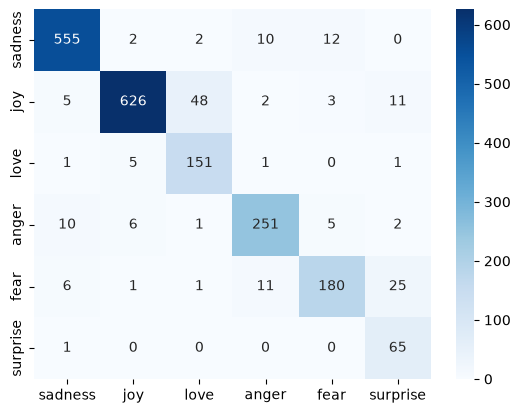

In [29]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

## 9. Final Predictions
Test the winning model on unseen sample sentences.

In [30]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


## 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [31]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)